In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import datetime
import matplotlib as mpl

In [2]:
df = pd.read_csv('data/final_dataframes/main_training_dataframe.csv')


In [3]:
df.head()

,Unnamed: 0,time,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,MonthDay
0,0,2019-01-01 00:00:00,-7.4,81,17.9,146,-5.7,87,12.4,100,...,88,13.0,132,-5.6,84,18.8,144,1933.0,2019,01-01
1,1,2019-01-01 01:00:00,-7.0,80,18.9,145,-5.8,87,13.6,102,...,87,14.6,130,-5.8,84,19.2,142,1996.0,2019,01-01
2,2,2019-01-01 02:00:00,-7.1,80,21.3,146,-5.9,88,12.9,103,...,89,16.0,121,-5.8,83,17.9,142,1936.0,2019,01-01
3,3,2019-01-01 03:00:00,-6.8,80,22.2,148,-5.9,90,15.9,103,...,87,16.2,122,-6.0,84,15.0,136,2023.0,2019,01-01
4,4,2019-01-01 04:00:00,-6.8,81,22.4,143,-5.9,90,15.6,109,...,86,16.1,114,-6.3,86,15.8,131,2147.0,2019,01-01


In [4]:
df.tail()

,Unnamed: 0,time,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,MonthDay
35059,35059,2022-12-31 19:00:00,3.1,92,7.7,217,1.1,94,5.6,45,...,97,4.9,234,1.8,98,4.6,198,145.0,2022,12-31
35060,35060,2022-12-31 20:00:00,2.6,97,2.5,188,1.0,95,4.6,51,...,98,1.1,90,2.2,100,5.1,188,118.0,2022,12-31
35061,35061,2022-12-31 21:00:00,2.9,96,2.7,203,0.8,96,6.0,17,...,99,1.8,90,3.4,99,2.2,189,31.0,2022,12-31
35062,35062,2022-12-31 22:00:00,3.8,94,3.1,54,0.6,96,5.2,335,...,99,3.3,96,3.0,100,1.8,127,33.0,2022,12-31
35063,35063,2022-12-31 23:00:00,1.2,100,4.7,86,0.6,96,6.1,332,...,100,3.3,84,1.6,100,4.7,122,45.0,2022,12-31


Text(0.5, 1.0, 'Mean: 1303.409 Std: 829.3')

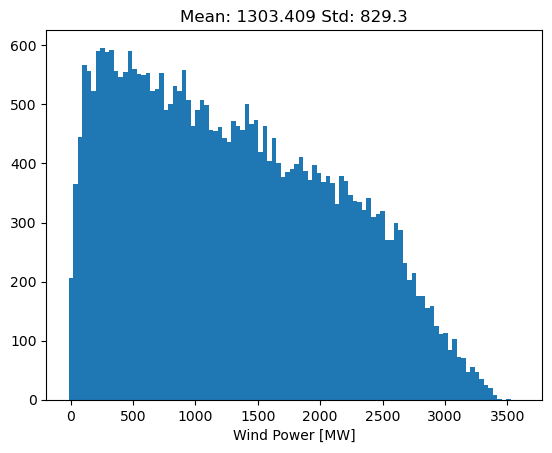

In [33]:
plt.hist(df.Wind, range=[-15, 3600], bins=100)
plt.xlabel('Wind Power [MW]')
plt.title('Mean: '+str(df.Wind.mean())[:8]+' Std: '+str(df.Wind.std())[:5])

In [22]:
df.Wind.mean()

np.float64(1303.409964636094)

In [24]:
df.Wind.std()

np.float64(829.374475587316)

In [27]:
df.Wind.median()

np.float64(1214.0)

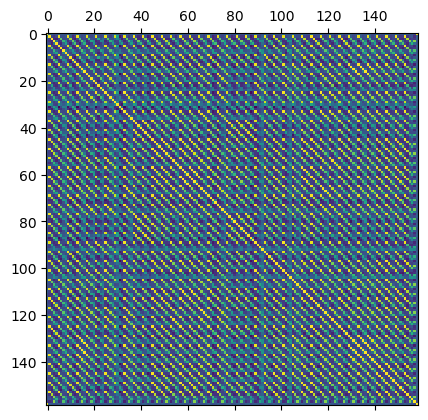

In [6]:
corrs = df.corr(numeric_only=True)
plt.matshow(corrs)
# for (i, j), z in np.ndenumerate(corrs):
#     plt.text(j, i, '{:0.1f}'.format(z), ha='center', va='center',
#             bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))


In [7]:
nfarms = 0
for column in df.columns:
    if 'temperature' in column:
        nfarms += 1

In [8]:
df['mean_temperature'] = df[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
df['mean_humidity'] = df[[f'relative_humidity_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
df['mean_windspeed'] = df[[f'wind_speed_10m_{i}' for i in range(1, nfarms)]].mean(axis=1)



Text(0, 0.5, 'Generated power')

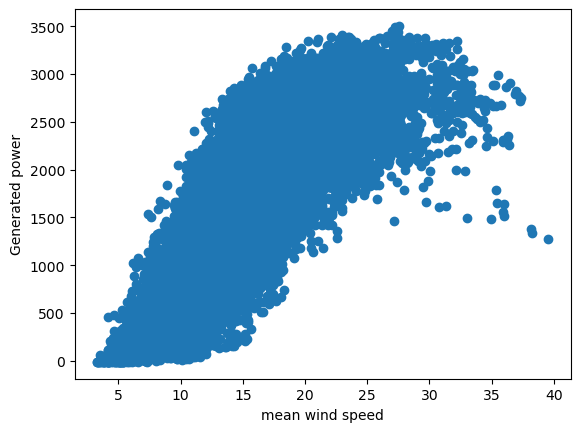

In [9]:
plt.scatter(x=df.mean_windspeed, y=df.Wind)
plt.xlabel('mean wind speed')
plt.ylabel('Generated power')

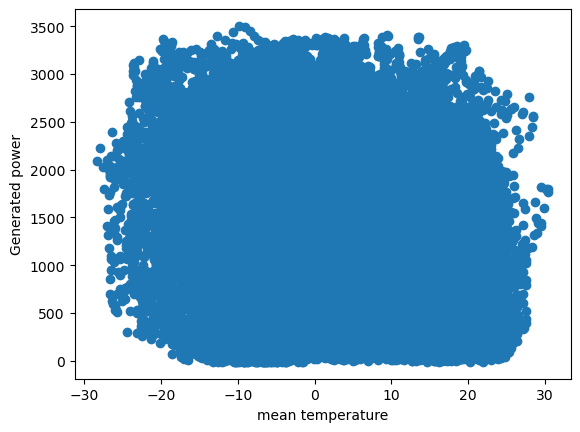

In [11]:
plt.scatter(x=df['mean_temperature'], y=df.Wind)
plt.xlabel('mean temperature')
plt.ylabel('Generated power')
plt.show()

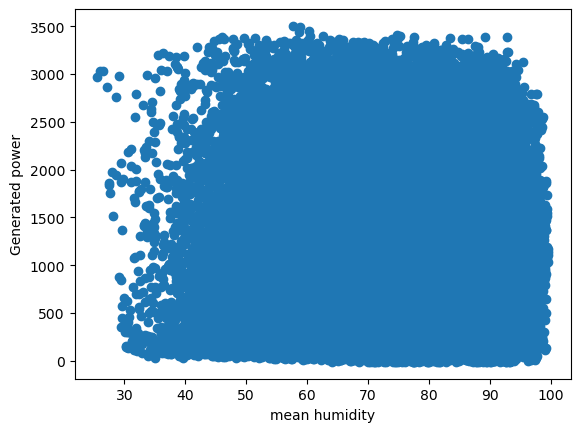

In [12]:
plt.scatter(x=df['mean_humidity'], y=df.Wind)
plt.xlabel('mean humidity')
plt.ylabel('Generated power')
plt.show()

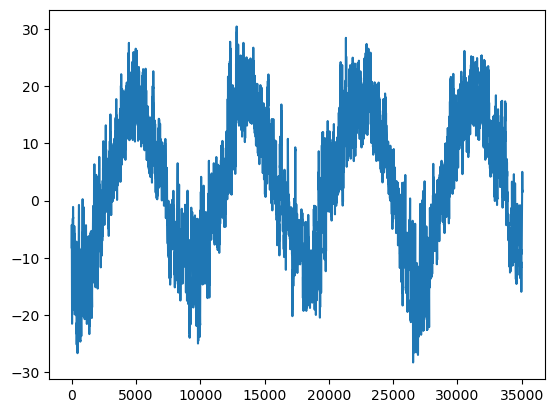

In [13]:
plt.plot(df[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1))

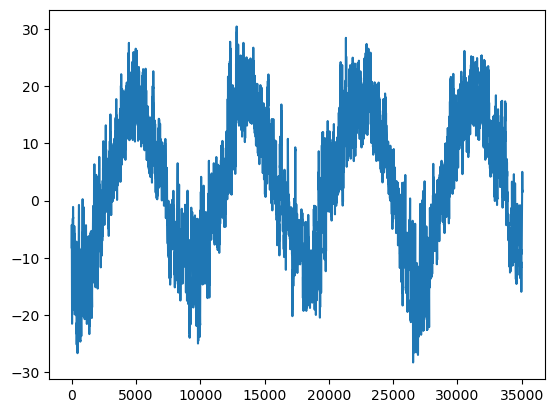

In [20]:
plt.plot(df[f'mean_temperature'])

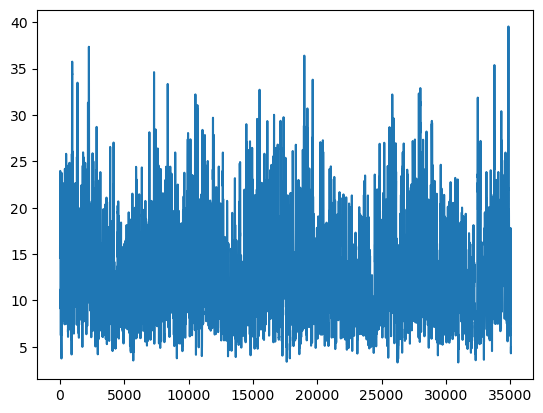

In [21]:
plt.plot(df[f'mean_windspeed'])

Text(0, 0.5, 'Wind power')

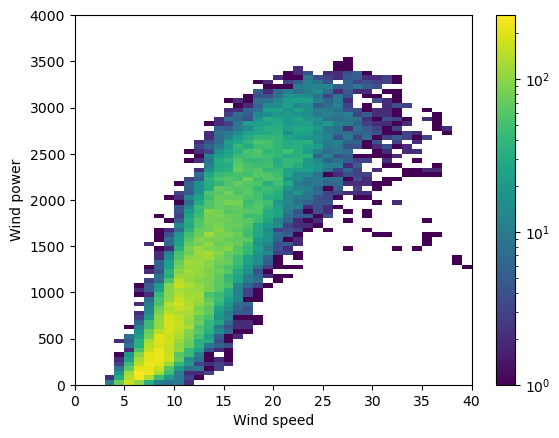

In [ ]:
fig, ax = plt.subplots()
h = ax.hist2d(x=df.mean_windspeed, y=df.Wind, bins=(40, 80), range=[[0, 40], [0, 4000]], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Wind speed')
ax.set_ylabel('Wind power')

Text(0, 0.5, 'Wind power')

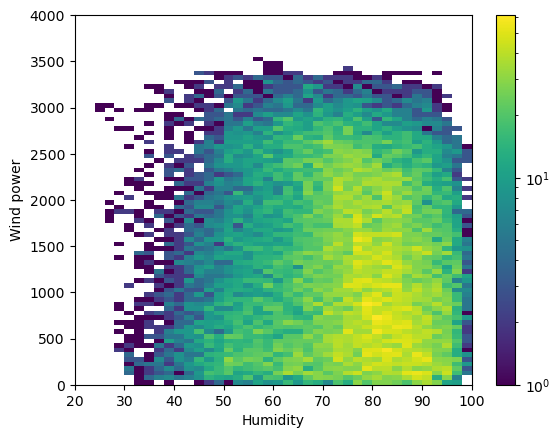

In [ ]:
fig, ax = plt.subplots()
h = ax.hist2d(x=df.mean_humidity, y=df.Wind, bins=(40, 80), range=[[20, 100], [0, 4000]], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Humidity')
ax.set_ylabel('Wind power')

Text(0, 0.5, 'Wind power')

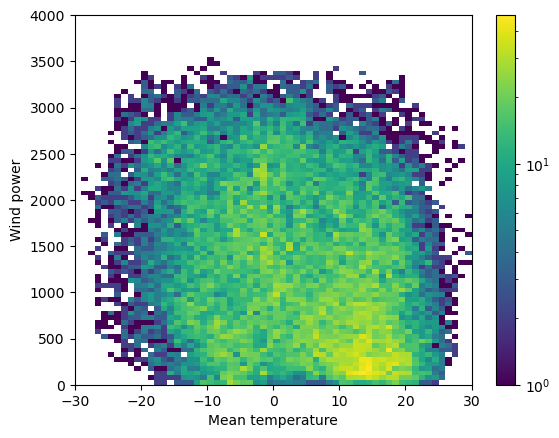

In [ ]:
fig, ax = plt.subplots()
h = ax.hist2d(x=df.mean_temperature, y=df.Wind, bins=(60, 80), range=[[-30, 30], [0, 4000]], norm=mpl.colors.LogNorm(),)
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('Mean temperature')
ax.set_ylabel('Wind power')

In [14]:
wfs = pd.read_csv('/Users/andreafodor/erdos_summer2025/windPower/data/raw_data/hydroquebec_wind_farms.csv')

In [15]:
wfs.columns

Index(['name', 'project_type', 'capacity_MW', 'region', 'status',
       'commissioning_date', 'latitude', 'longitude'],
      dtype='object')

In [16]:
sum(wfs.query('status=="In service"').capacity_MW)

3721.75

In [17]:
df["datetime"] = pd.to_datetime(df["time"])

Text(0, 0.5, 'Wind power')

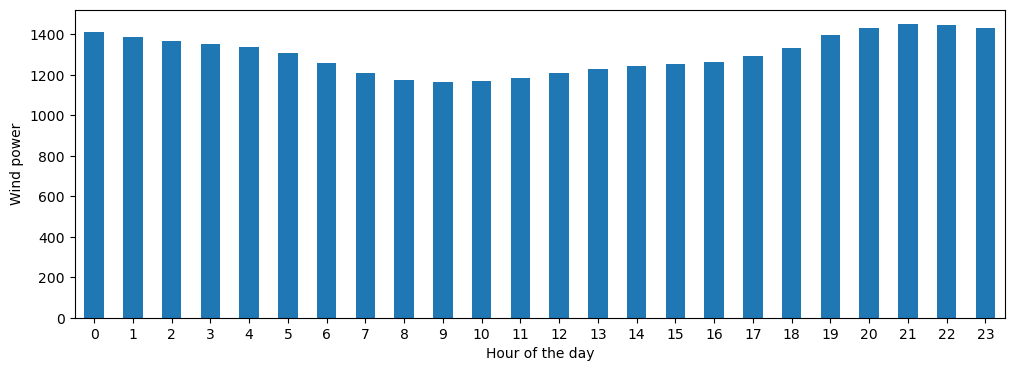

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4))

df.groupby(df["datetime"].dt.hour)["Wind"].mean().plot(

    kind='bar', rot=0, ax=axs
)

plt.xlabel("Hour of the day")
plt.ylabel("Wind power")


Text(0, 0.5, 'Wind power')

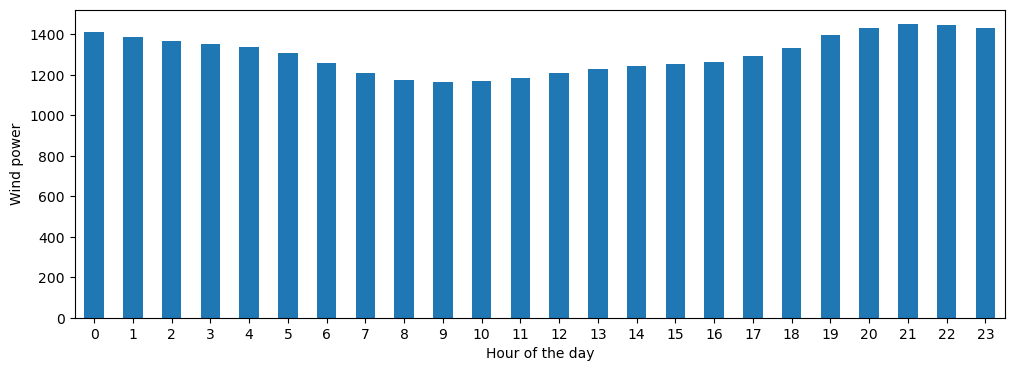

In [ ]:
fig, axs = plt.subplots(figsize=(12, 4))

df.groupby(df["datetime"].dt.)["Wind"].mean().plot(

    kind='bar', rot=0, ax=axs
)

plt.xlabel("Hour of the day")
plt.ylabel("Wind power")


Text(0, 0.5, 'Wind power')

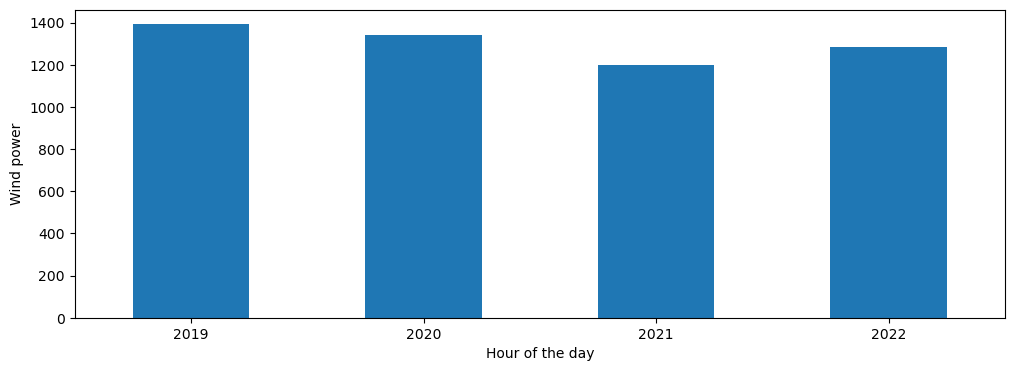

In [19]:
fig, axs = plt.subplots(figsize=(12, 4))

df.groupby(df["datetime"].dt.year)["Wind"].mean().plot(

    kind='bar', rot=0, ax=axs
)

plt.xlabel("Hour of the day")
plt.ylabel("Wind power")
